# 🎵 Spotify Hit Predictor + Song DNA Analyzer

---

**Question:** What makes a song a hit? Can we predict it — and reverse-engineer the formula?

This project combines **supervised ML** (predict hit or flop) with **unsupervised discovery** (find hidden song archetypes) to decode the DNA of popular music.

**What this project covers:**
- Deep EDA with rich visualizations (trends, distributions, correlations)
- Feature engineering from audio features
- Class imbalance handling with SMOTE
- 7-model benchmark with Stratified K-Fold cross-validation
- Hyperparameter tuning (RandomizedSearchCV)
- PyTorch deep neural network on tabular data
- K-Means clustering to discover hidden song archetypes
- PCA + t-SNE dimensionality reduction for cluster visualization
- SHAP explainability — what features make a hit?
- Final "hit recipe" insights dashboard with radar charts

**Dataset:** Spotify Tracks Dataset (~114k songs, 20+ audio features)  
**Target:** Popularity score → binarized into Hit (top 25%) vs Non-hit

---

## 📦 Section 0: Setup

In [1]:
from IPython.display import clear_output
%pip install kagglehub xgboost catboost imbalanced-learn shap -q
clear_output()
print('All libraries installed.')

All libraries installed.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
import shap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports done.')
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')


Imports done.
PyTorch: 2.5.1+cu121 | CUDA: True
Using: cuda


---
## 📊 Section 1: Load Data

In [3]:
path = kagglehub.dataset_download('maharshipandya/-spotify-tracks-dataset')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head()

Raw dataset shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
print('=== Column Types ===')
print(df_raw.dtypes)
print(f'\n=== Missing Values ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {df_raw.isnull().sum().sum()}')

=== Column Types ===
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

=== Missing Values ===
artists       1
album_name    1
track_name    1
dtype: int64

Total missing: 3


In [5]:
# ── Clean the dataset ─────────────────────────────────────────────────────────
df = df_raw.copy()

# Drop rows with missing values
df.dropna(inplace=True)

# Drop duplicates by track_id if it exists
if 'track_id' in df.columns:
    df.drop_duplicates(subset='track_id', inplace=True)

# Drop non-feature columns (IDs, names, etc.)
drop_cols = [c for c in ['track_id', 'Unnamed: 0'] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print(f'Cleaned dataset shape: {df.shape}')
df.head()

Cleaned dataset shape: (89740, 19)


,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


---
## 🔍 Section 2: Deep Exploratory Data Analysis

Understanding the music landscape before building any model.

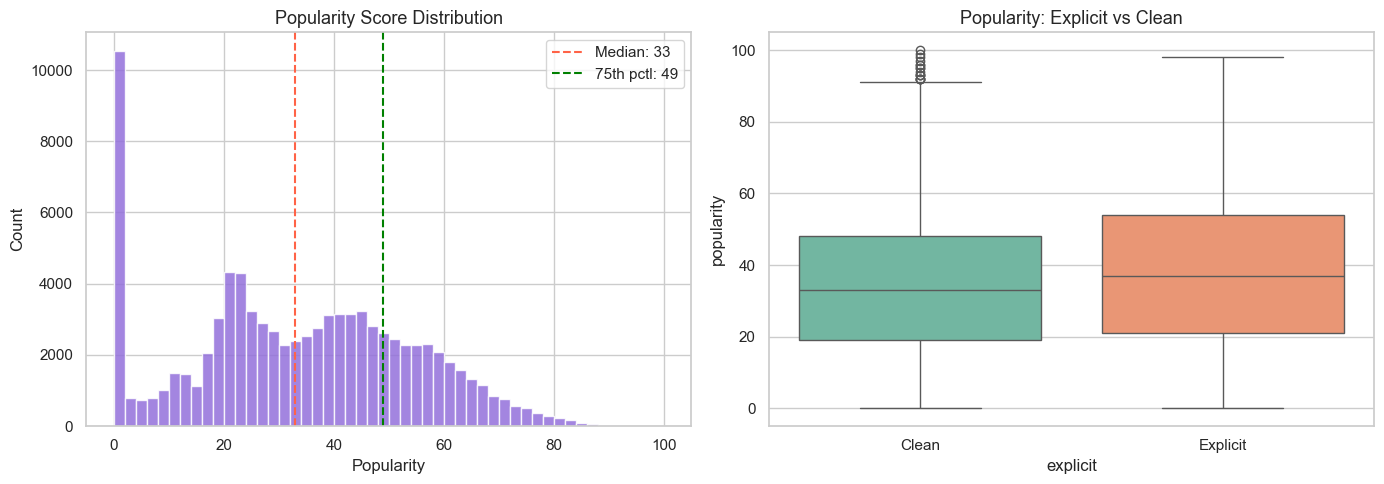

In [6]:
# ── Popularity distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['popularity'], bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(df['popularity'].median(), color='tomato', linestyle='--', label=f'Median: {df["popularity"].median():.0f}')
axes[0].axvline(df['popularity'].quantile(0.75), color='green', linestyle='--', label=f'75th pctl: {df["popularity"].quantile(0.75):.0f}')
axes[0].set_title('Popularity Score Distribution', fontsize=13)
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot by explicit flag
if 'explicit' in df.columns:
    sns.boxplot(data=df, x='explicit', y='popularity', ax=axes[1], palette='Set2')
    axes[1].set_title('Popularity: Explicit vs Clean', fontsize=13)
    axes[1].set_xticklabels(['Clean', 'Explicit'])

plt.tight_layout()
plt.show()

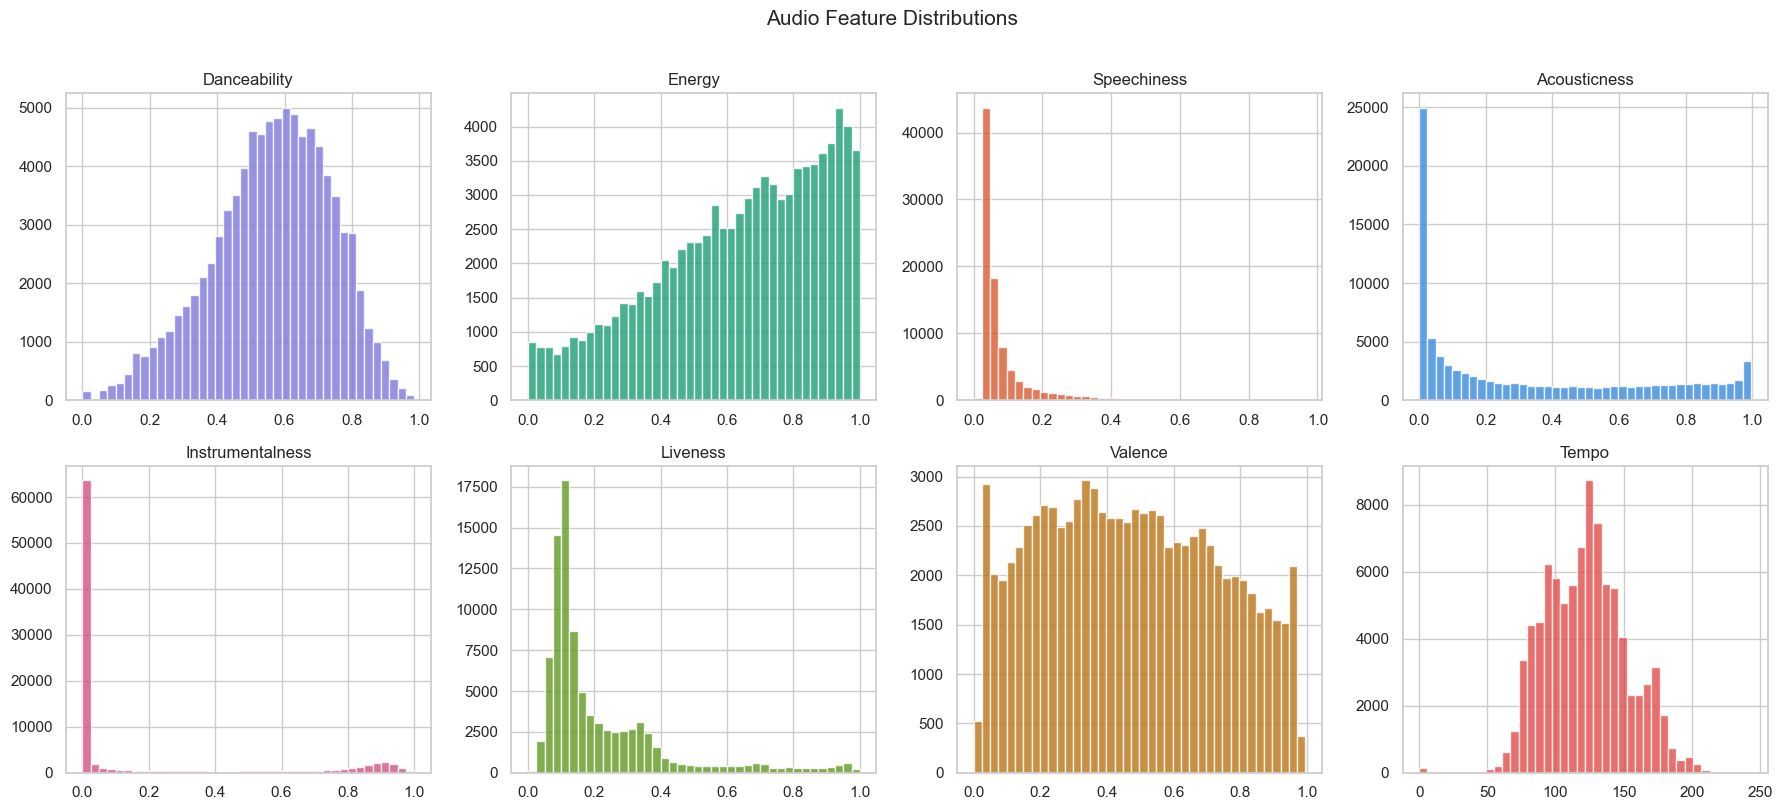

In [7]:
# ── Audio feature distributions ───────────────────────────────────────────────
audio_features = ['danceability', 'energy', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo']
audio_features = [f for f in audio_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD',
          '#D4537E', '#639922', '#BA7517', '#E24B4A']

for i, feat in enumerate(audio_features[:8]):
    axes[i].hist(df[feat], bins=40, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(feat.capitalize(), fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Audio Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

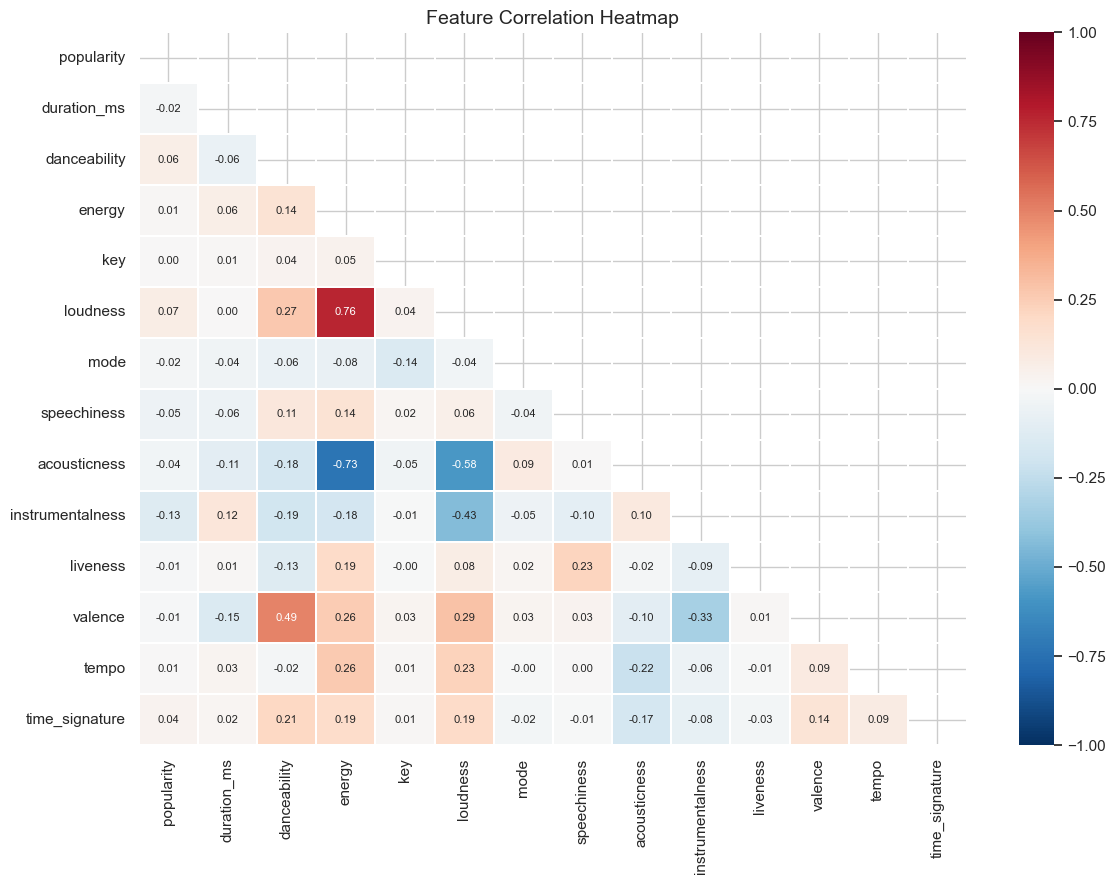

In [8]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

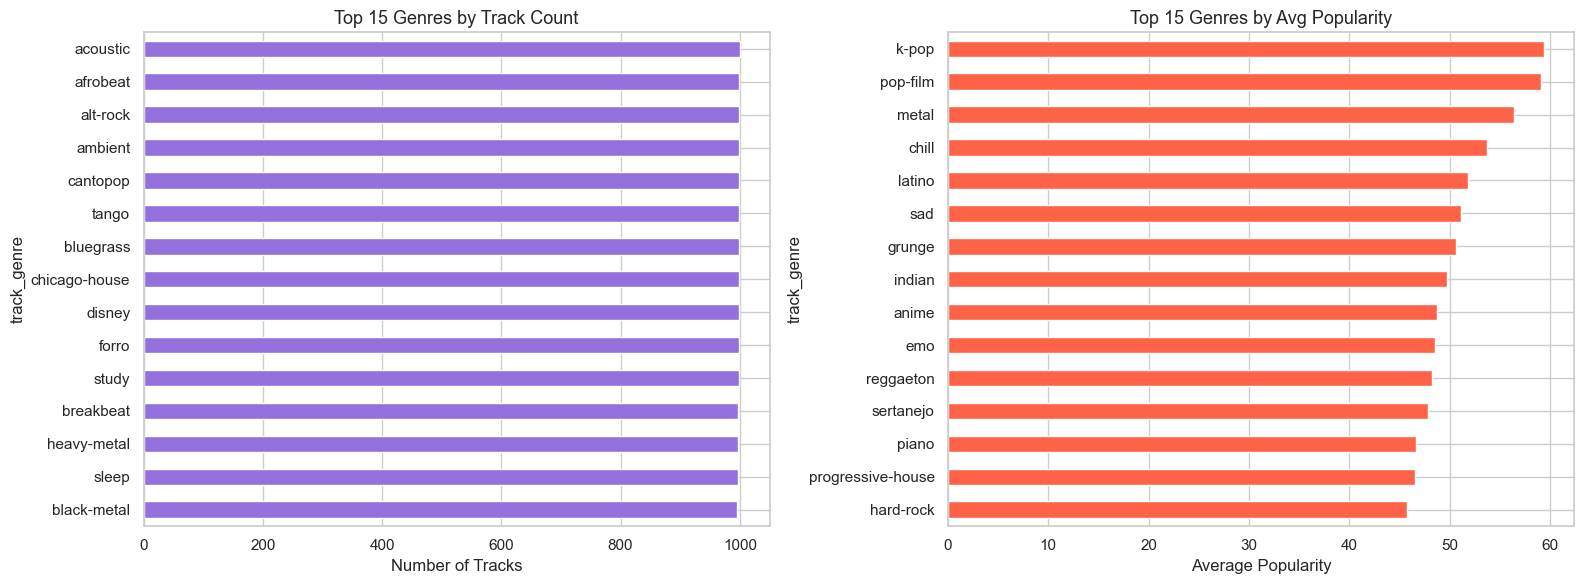

In [9]:
# ── Top 15 genres by count ────────────────────────────────────────────────────
if 'track_genre' in df.columns:
    top_genres = df['track_genre'].value_counts().head(15)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    top_genres.plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='white')
    axes[0].set_title('Top 15 Genres by Track Count', fontsize=13)
    axes[0].set_xlabel('Number of Tracks')
    axes[0].invert_yaxis()

    # Average popularity per genre
    genre_pop = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(15)
    genre_pop.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
    axes[1].set_title('Top 15 Genres by Avg Popularity', fontsize=13)
    axes[1].set_xlabel('Average Popularity')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

Hit threshold (75th percentile): popularity >= 49.0


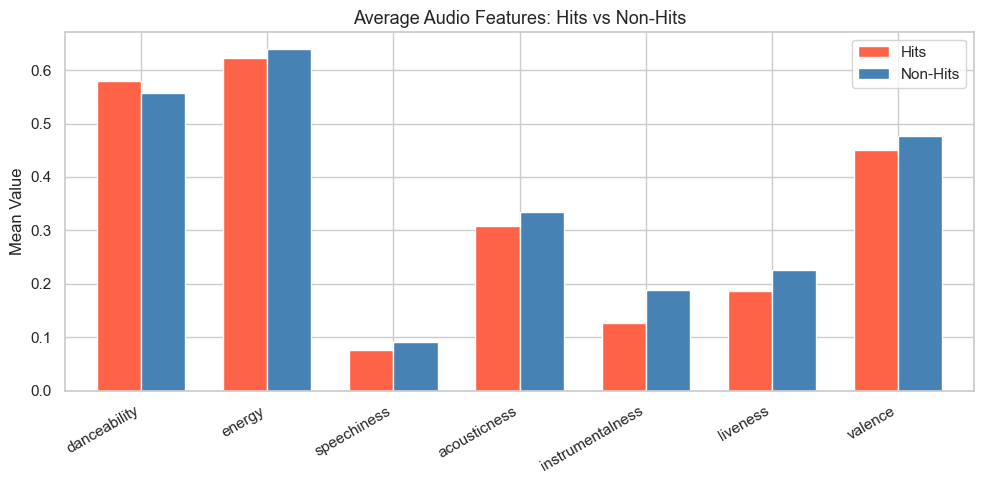


Hits: 22,520 tracks (25.1%)
Non-Hits: 67,220 tracks (74.9%)


In [10]:
# ── Audio profiles: Hits vs Flops (radar-style comparison) ────────────────────
threshold = df['popularity'].quantile(0.75)
print(f'Hit threshold (75th percentile): popularity >= {threshold}')

hits = df[df['popularity'] >= threshold]
flops = df[df['popularity'] < threshold]

radar_feats = [f for f in ['danceability', 'energy', 'speechiness', 'acousticness',
               'instrumentalness', 'liveness', 'valence'] if f in df.columns]

hit_means = hits[radar_feats].mean()
flop_means = flops[radar_feats].mean()

comparison = pd.DataFrame({'Hits': hit_means, 'Non-Hits': flop_means})

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind='bar', ax=ax, color=['tomato', 'steelblue'], edgecolor='white', width=0.7)
ax.set_title('Average Audio Features: Hits vs Non-Hits', fontsize=13)
ax.set_ylabel('Mean Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nHits: {len(hits):,} tracks ({len(hits)/len(df)*100:.1f}%)')
print(f'Non-Hits: {len(flops):,} tracks ({len(flops)/len(df)*100:.1f}%)')

---
## ⚙️ Section 3: Feature Engineering & Preprocessing

In [11]:
df_feat = df.copy()

# ── Create binary target ──────────────────────────────────────────────────────
threshold = df_feat['popularity'].quantile(0.75)
df_feat['is_hit'] = (df_feat['popularity'] >= threshold).astype(int)
df_feat.drop(columns=['popularity'], inplace=True)

# ── Engineered features ───────────────────────────────────────────────────────
if 'danceability' in df_feat.columns and 'energy' in df_feat.columns:
    df_feat['dance_energy_ratio'] = df_feat['danceability'] / (df_feat['energy'] + 0.001)

if 'valence' in df_feat.columns and 'energy' in df_feat.columns:
    df_feat['mood_score'] = (df_feat['valence'] + df_feat['energy']) / 2

if 'acousticness' in df_feat.columns and 'instrumentalness' in df_feat.columns:
    df_feat['acoustic_signature'] = df_feat['acousticness'] * 0.6 + df_feat['instrumentalness'] * 0.4

if 'tempo' in df_feat.columns:
    df_feat['tempo_bucket'] = pd.cut(df_feat['tempo'],
                                      bins=[0, 90, 120, 140, 300],
                                      labels=[0, 1, 2, 3])
    df_feat['tempo_bucket'] = df_feat['tempo_bucket'].cat.add_categories(-1).fillna(-1).astype(int)

if 'speechiness' in df_feat.columns and 'liveness' in df_feat.columns:
    df_feat['vocal_presence'] = df_feat['speechiness'] + df_feat['liveness']

if 'duration_ms' in df_feat.columns:
    df_feat['duration_min'] = df_feat['duration_ms'] / 60000
    df_feat.drop(columns=['duration_ms'], inplace=True)

# ── Encode categoricals ───────────────────────────────────────────────────────
# Drop text columns that aren't useful for modeling
text_cols = [c for c in ['track_name', 'artists', 'album_name'] if c in df_feat.columns]
df_feat.drop(columns=text_cols, inplace=True)

# Encode remaining categoricals
cat_cols = df_feat.select_dtypes(include='object').columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col].astype(str))
    le_dict[col] = le

# Encode boolean columns
bool_cols = df_feat.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    df_feat[col] = df_feat[col].astype(int)

print(f'Final feature count: {df_feat.shape[1] - 1}')
print(f'Engineered features: dance_energy_ratio, mood_score, acoustic_signature, tempo_bucket, vocal_presence, duration_min')
df_feat.head()

Final feature count: 20
Engineered features: dance_energy_ratio, mood_score, acoustic_signature, tempo_bucket, vocal_presence, duration_min


,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,tempo,time_signature,track_genre,is_hit,dance_energy_ratio,mood_score,acoustic_signature,tempo_bucket,vocal_presence,duration_min
0,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,...,87.917,4,0,1,1.463203,0.5880,0.019320,0,0.5010,3.844433
1,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,...,77.489,4,0,1,2.514970,0.2165,0.554402,0,0.1773,2.493500
2,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,...,76.332,4,0,1,1.216667,0.2395,0.126000,0,0.1727,3.513767
3,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,...,181.740,3,0,1,4.389439,0.1013,0.543028,3,0.1683,3.365550
4,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,...,119.949,4,0,1,1.391892,0.3050,0.281400,1,0.1355,3.314217


---
## 🔀 Section 4: Train/Test Split + SMOTE

In [12]:
X = df_feat.drop('is_hit', axis=1)
y = df_feat['is_hit']

feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {dict(y_train.value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_res).value_counts())}')
print(f'Test set:     {dict(y_test.value_counts())}')

Before SMOTE: {0: np.int64(53776), 1: np.int64(18016)}
After  SMOTE: {0: np.int64(53776), 1: np.int64(53776)}
Test set:     {0: np.int64(13444), 1: np.int64(4504)}


---
## 🤖 Section 5: Multi-Model Benchmark (7 Models, 5-Fold CV)

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         eval_metric='logloss', verbosity=0, random_state=SEED),
    'CatBoost':            CatBoostClassifier(n_estimators=300, depth=6, learning_rate=0.05,
                                              verbose=0, random_state=SEED),
}

results = {name: {'accuracy': [], 'f1': [], 'roc_auc': [], 'precision': [], 'recall': []}
           for name in models}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_res, y_train_res)):
    X_tr, X_val = X_train_res[tr_idx], X_train_res[val_idx]
    y_tr, y_val = y_train_res[tr_idx], y_train_res[val_idx]

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        results[name]['accuracy'].append(accuracy_score(y_val, y_pred))
        results[name]['f1'].append(f1_score(y_val, y_pred))
        results[name]['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        results[name]['recall'].append(recall_score(y_val, y_pred))
        results[name]['roc_auc'].append(roc_auc_score(y_val, y_proba))

    print(f'Fold {fold+1}/5 complete.')

print('\nCross-validation done!')

Fold 1/5 complete.
Fold 2/5 complete.
Fold 3/5 complete.
Fold 4/5 complete.
Fold 5/5 complete.

Cross-validation done!


=== 5-Fold Cross-Validation Results ===
                     Accuracy      F1  ROC-AUC  Precision  Recall
XGBoost                0.8229  0.8156   0.9109     0.8509  0.7831
CatBoost               0.8209  0.8079   0.9095     0.8711  0.7533
Random Forest          0.7388  0.7604   0.8198     0.7024  0.8289
Decision Tree          0.6636  0.7043   0.7239     0.6285  0.8012
Logistic Regression    0.6029  0.6156   0.6417     0.5965  0.6360


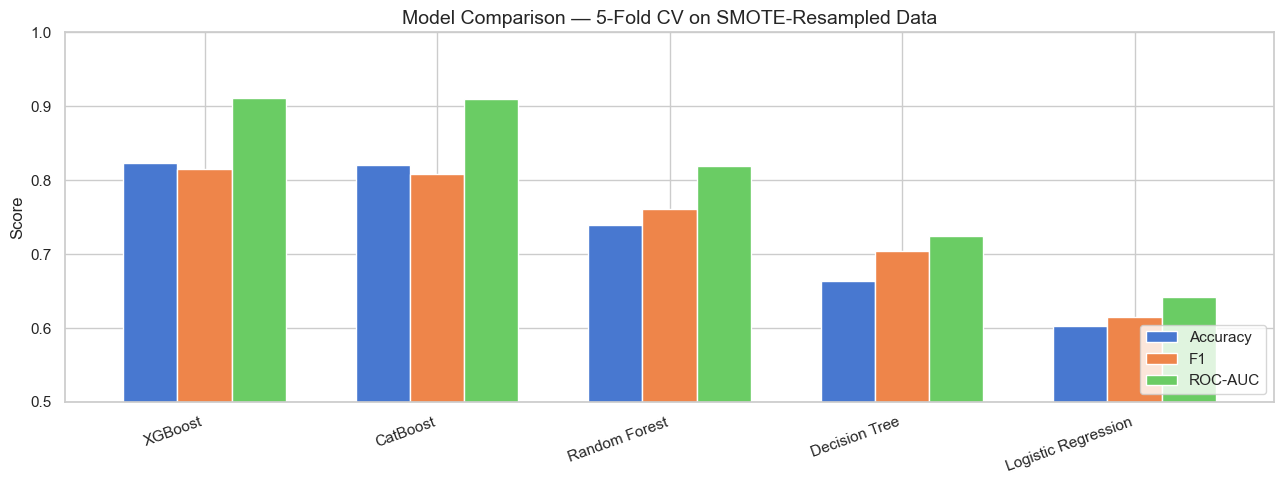

In [14]:
summary = pd.DataFrame({
    name: {
        'Accuracy':  np.mean(results[name]['accuracy']),
        'F1':        np.mean(results[name]['f1']),
        'ROC-AUC':   np.mean(results[name]['roc_auc']),
        'Precision': np.mean(results[name]['precision']),
        'Recall':    np.mean(results[name]['recall']),
    }
    for name in results
}).T.round(4).sort_values('ROC-AUC', ascending=False)

print('=== 5-Fold Cross-Validation Results ===')
print(summary.to_string())

summary[['Accuracy', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 5), edgecolor='white', width=0.7
)
plt.title('Model Comparison — 5-Fold CV on SMOTE-Resampled Data', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 🎯 Section 6: Hyperparameter Tuning

In [15]:
param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 5, 6, 8, 10],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(eval_metric='logloss', verbosity=0, random_state=SEED)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_res, y_train_res)

print(f'\nBest ROC-AUC: {random_search.best_score_:.4f}')
print(f'Best params:  {random_search.best_params_}')

best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best ROC-AUC: 0.9385
Best params:  {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.7}


---
## 🧠 Section 7: PyTorch Deep Neural Network

In [16]:
class HitNet(nn.Module):
    """Deep neural network for hit prediction with BatchNorm + Dropout."""
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Split SMOTE data for NN validation
X_nn_tr, X_nn_val, y_nn_tr, y_nn_val = train_test_split(
    X_train_res, y_train_res, test_size=0.15, random_state=SEED
)

def make_loader(X, y, batch_size=128, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y if isinstance(y, np.ndarray) else y.values, dtype=torch.float32)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_nn_tr, y_nn_tr)
val_loader   = make_loader(X_nn_val, y_nn_val, batch_size=512, shuffle=False)

input_dim = X_train_res.shape[1]
nn_model  = HitNet(input_dim).to(device)
optimizer = AdamW(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.BCEWithLogitsLoss()

print(nn_model)
print(f'Parameters: {sum(p.numel() for p in nn_model.parameters()):,}')

HitNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 47,489


In [17]:
EPOCHS = 50
train_losses, val_losses, val_aucs = [], [], []
best_auc = 0.0


for epoch in range(EPOCHS):
    nn_model.train()
    ep_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(Xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    scheduler.step()
    train_losses.append(ep_loss / len(train_loader))

    nn_model.eval()
    preds, trues = [], []
    v_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = nn_model(Xb)
            v_loss += criterion(logits, yb).item()
            preds.extend(torch.sigmoid(logits).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    val_losses.append(v_loss / len(val_loader))
    auc = roc_auc_score(trues, preds)
    val_aucs.append(auc)

    if auc > best_auc:
        best_auc = auc
        torch.save(nn_model.state_dict(), 'best_hitnet.pth')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f} | Val AUC: {auc:.4f}')

print(f'\nBest validation AUC: {best_auc:.4f}')

Epoch  10/50 | Train Loss: 0.5968 | Val Loss: 0.5780 | Val AUC: 0.7620
Epoch  20/50 | Train Loss: 0.5777 | Val Loss: 0.5571 | Val AUC: 0.7829
Epoch  30/50 | Train Loss: 0.5656 | Val Loss: 0.5474 | Val AUC: 0.7930
Epoch  40/50 | Train Loss: 0.5596 | Val Loss: 0.5455 | Val AUC: 0.7978
Epoch  50/50 | Train Loss: 0.5567 | Val Loss: 0.5405 | Val AUC: 0.8000

Best validation AUC: 0.8003


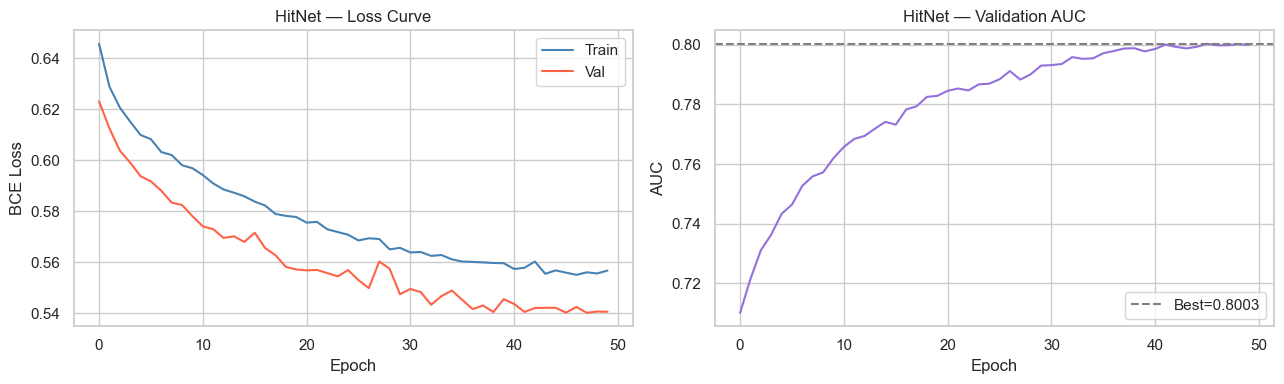

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label='Train', color='steelblue')
axes[0].plot(val_losses,   label='Val',   color='tomato')
axes[0].set_title('HitNet — Loss Curve')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss'); axes[0].legend()

axes[1].plot(val_aucs, color='mediumpurple')
axes[1].axhline(best_auc, ls='--', color='gray', label=f'Best={best_auc:.4f}')
axes[1].set_title('HitNet — Validation AUC')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC'); axes[1].legend()
plt.tight_layout()
plt.show()

---
## 📈 Section 8: Final Test Set Evaluation

In [19]:
def eval_model(model, X, y, name, is_torch=False):
    if is_torch:
        model.eval()
        with torch.no_grad():
            logits = model(torch.tensor(X, dtype=torch.float32).to(device))
            proba  = torch.sigmoid(logits).cpu().numpy()
        pred = (proba > 0.5).astype(int)
    else:
        pred  = model.predict(X)
        proba = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, proba),
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall':    recall_score(y, pred),
    }, proba


test_rows, all_probas = [], {}

eval_models = {
    'Random Forest':   models['Random Forest'],
    'XGBoost (tuned)': best_xgb,
    'CatBoost':        models['CatBoost'],
}

for name, m in eval_models.items():
    row, p = eval_model(m, X_test_scaled, y_test, name)
    test_rows.append(row); all_probas[name] = p

nn_model.load_state_dict(torch.load('best_hitnet.pth'))
row, p = eval_model(nn_model, X_test_scaled, y_test, 'HitNet (PyTorch)', is_torch=True)
test_rows.append(row); all_probas['HitNet (PyTorch)'] = p

test_df = pd.DataFrame(test_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
print('=== Test Set Results ===')
print(test_df.round(4).to_string())

=== Test Set Results ===
                  Accuracy      F1  ROC-AUC  Precision  Recall
Model                                                         
XGBoost (tuned)     0.8061  0.5933   0.8375     0.6264  0.5635
CatBoost            0.7862  0.5332   0.8029     0.5898  0.4865
HitNet (PyTorch)    0.6503  0.5027   0.7347     0.3908  0.7043
Random Forest       0.6564  0.5026   0.7305     0.3947  0.6918


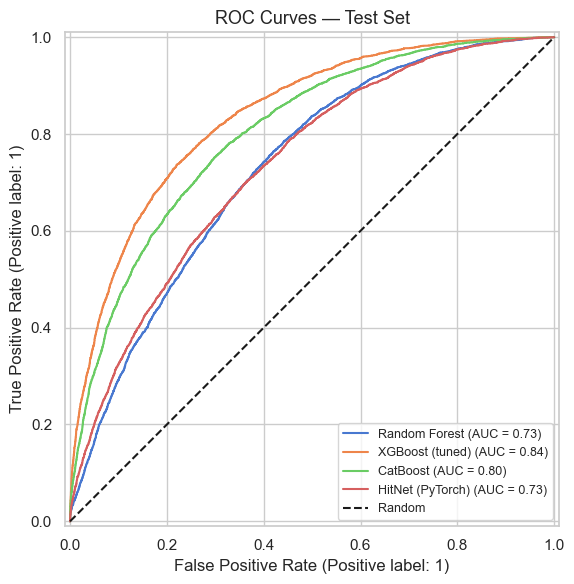

In [20]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba in all_probas.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves — Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

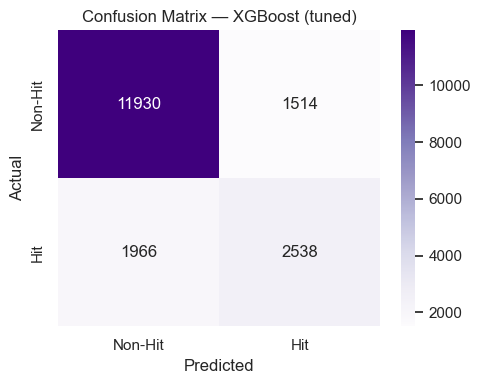

              precision    recall  f1-score   support

     Non-Hit       0.86      0.89      0.87     13444
         Hit       0.63      0.56      0.59      4504

    accuracy                           0.81     17948
   macro avg       0.74      0.73      0.73     17948
weighted avg       0.80      0.81      0.80     17948



In [21]:
# ── Confusion matrix for best model ───────────────────────────────────────────
best_name = test_df.index[0]
if best_name == 'HitNet (PyTorch)':
    y_pred_best = (all_probas[best_name] > 0.5).astype(int)
else:
    y_pred_best = eval_models[best_name].predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Non-Hit', 'Hit']))

---
## 🔬 Section 9: SHAP Explainability — What Makes a Hit?

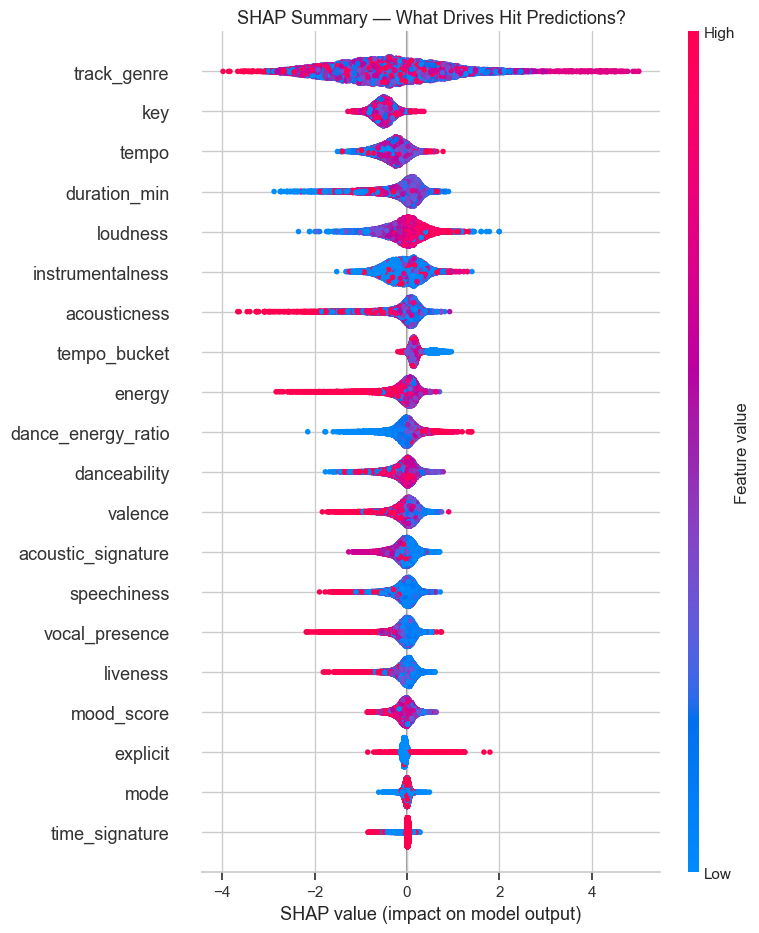

In [22]:
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# ── Global feature importance ─────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary — What Drives Hit Predictions?', fontsize=13)
plt.tight_layout()
plt.show()

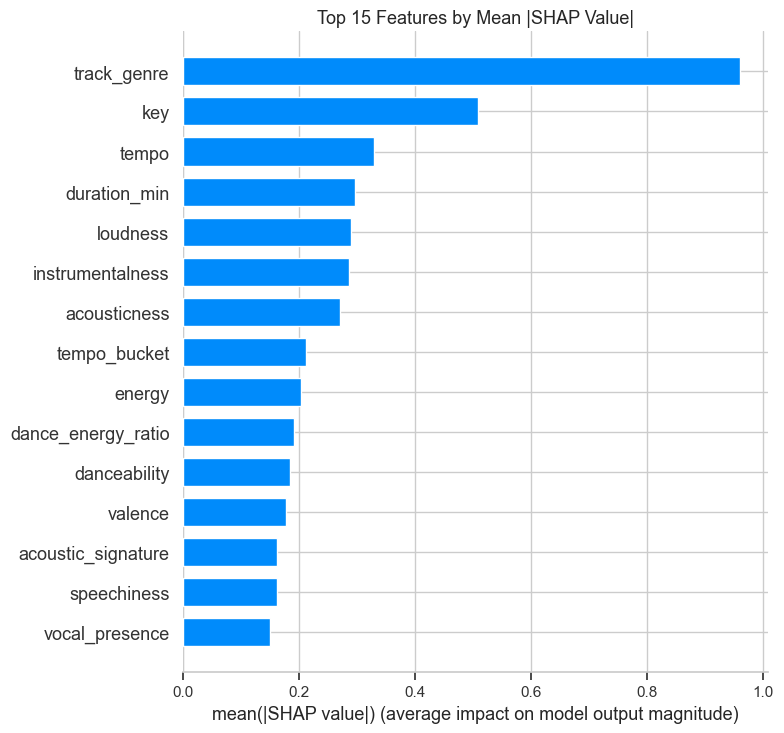

In [23]:
# ── Bar chart of mean |SHAP| ──────────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Features by Mean |SHAP Value|', fontsize=13)
plt.tight_layout()
plt.show()

Explaining prediction for test sample 5
True: Non-Hit
Pred: Hit


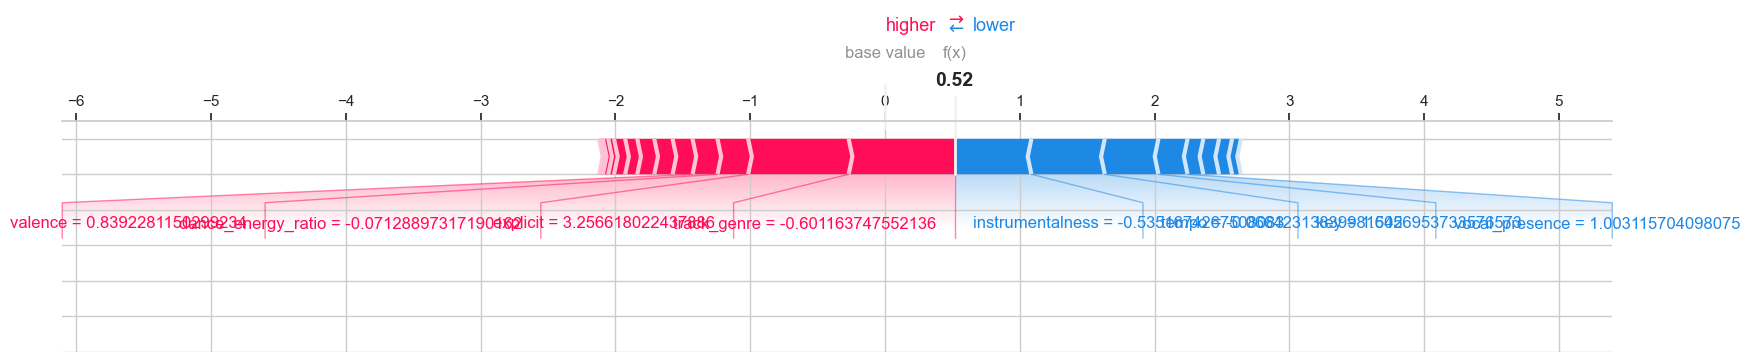

<Figure size 640x480 with 0 Axes>

In [24]:
# ── Explain one specific hit prediction ───────────────────────────────────────
hit_idx = np.where(y_pred_best == 1)[0][0]

print(f'Explaining prediction for test sample {hit_idx}')
print(f'True: {"Hit" if y_test.iloc[hit_idx] == 1 else "Non-Hit"}')
print(f'Pred: {"Hit" if y_pred_best[hit_idx] == 1 else "Non-Hit"}')

shap.force_plot(
    explainer.expected_value,
    shap_values[hit_idx],
    X_test_scaled[hit_idx],
    feature_names=feature_names,
    matplotlib=True
)
plt.tight_layout()
plt.show()

---
## 🧬 Section 10: Song DNA — Unsupervised Clustering

We use K-Means to discover hidden **song archetypes** — groups of songs that share a similar audio "personality", regardless of genre labels.

In [25]:
# ── Select audio features for clustering ──────────────────────────────────────
cluster_feats = [f for f in ['danceability', 'energy', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo']
                 if f in df.columns]

X_cluster = df[cluster_feats].dropna()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

print(f'Clustering on {len(X_cluster):,} songs using {len(cluster_feats)} audio features')

Clustering on 89,740 songs using 8 audio features


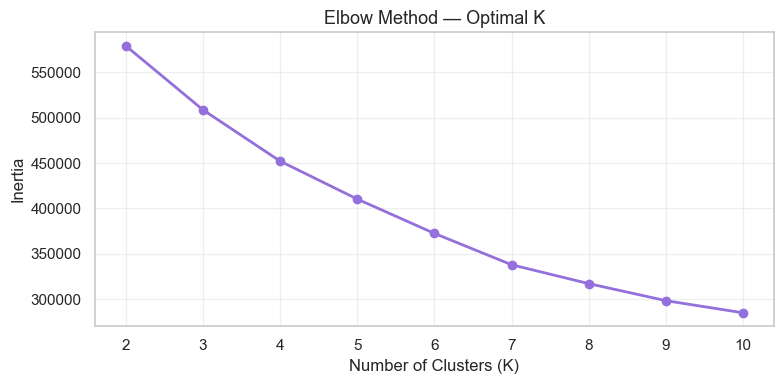

In [26]:
# ── Elbow method to find optimal K ────────────────────────────────────────────
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='mediumpurple', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# ── Fit K-Means with chosen K ─────────────────────────────────────────────────
K = 5
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

df_clustered = X_cluster.copy()
df_clustered['Cluster'] = cluster_labels

print(f'Cluster distribution:')
print(df_clustered['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    35109
1    20425
2    26185
3     6962
4     1059
Name: count, dtype: int64


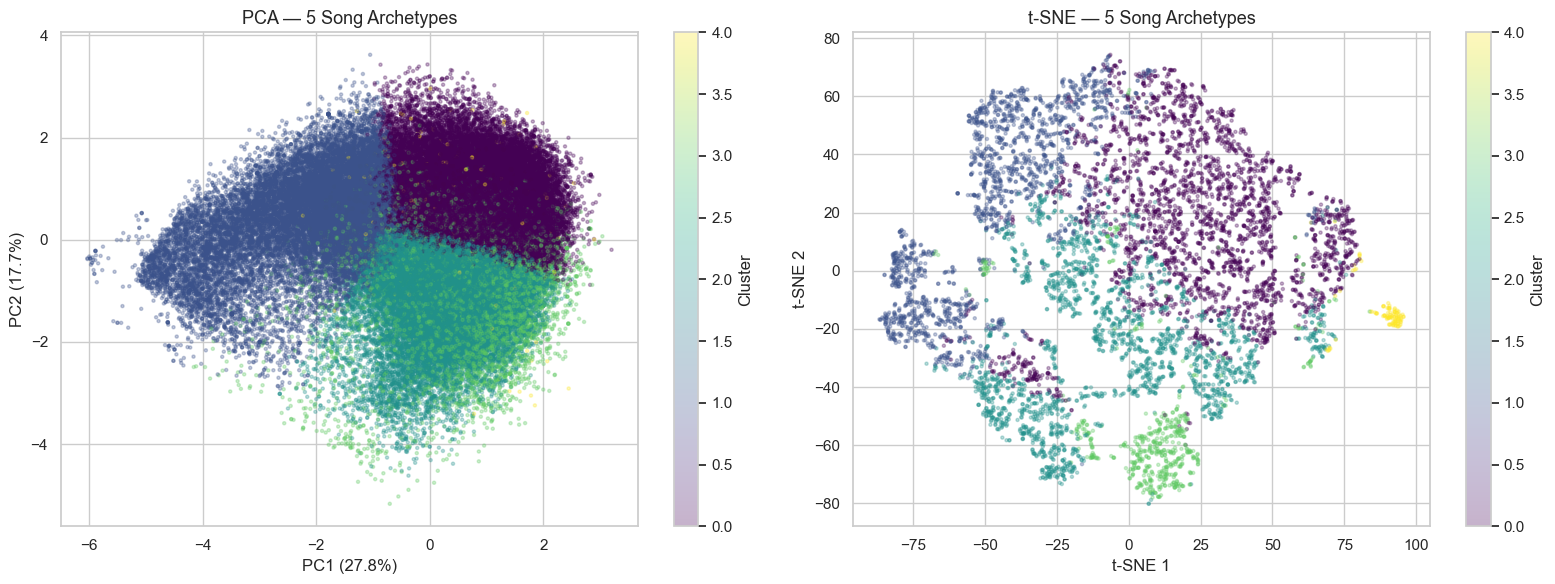

In [28]:
# ── PCA 2D visualization ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                          cmap='viridis', alpha=0.3, s=5)
axes[0].set_title(f'PCA — {K} Song Archetypes', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# ── t-SNE 2D visualization (on a sample for speed) ────────────────────────────
sample_idx = np.random.choice(len(X_cluster_scaled), size=min(8000, len(X_cluster_scaled)), replace=False)
X_sample = X_cluster_scaled[sample_idx]
labels_sample = cluster_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_sample,
                            cmap='viridis', alpha=0.3, s=5)
axes[1].set_title(f't-SNE — {K} Song Archetypes', fontsize=13)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

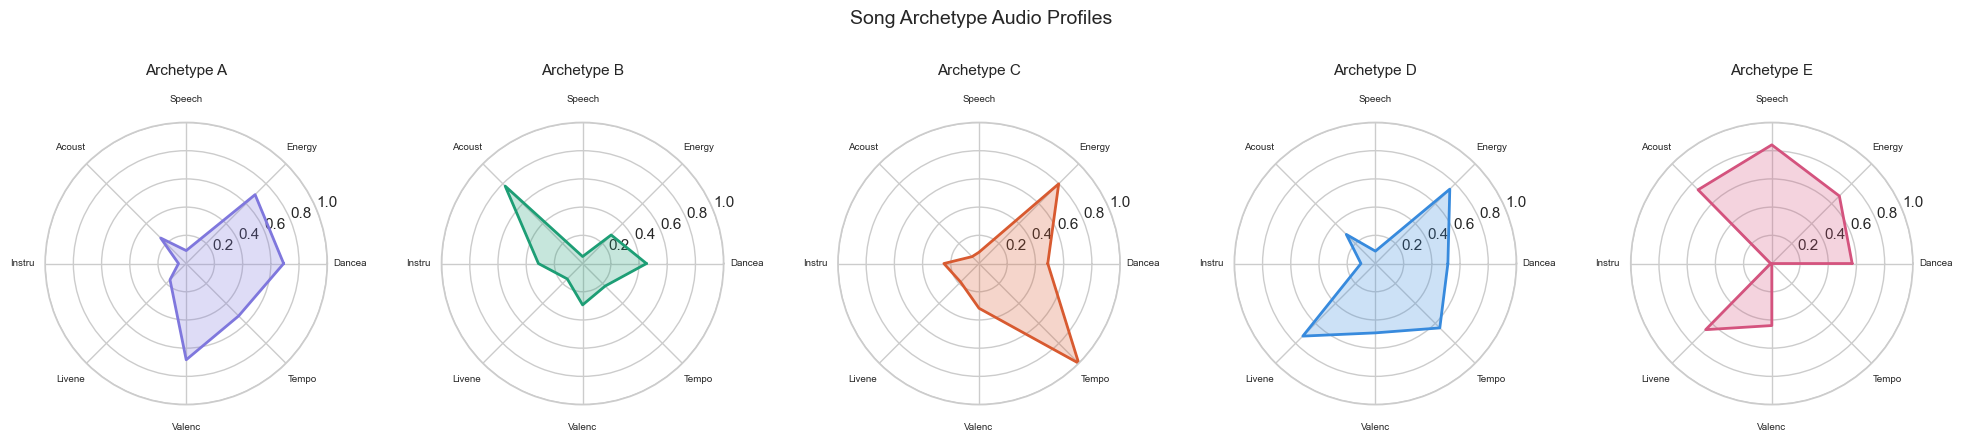


Cluster average profiles:
         danceability  energy  speechiness  acousticness  instrumentalness  liveness  valence  tempo
Cluster                                                                                             
0               0.691   0.691        0.092         0.256             0.055     0.163    0.682  0.526
1               0.453   0.286        0.050         0.776             0.313     0.154    0.293  0.226
2               0.487   0.799        0.080         0.069             0.249     0.185    0.317  1.000
3               0.514   0.746        0.088         0.292             0.103     0.728    0.491  0.646
4               0.570   0.677        0.841         0.739             0.009     0.663    0.440  0.000


In [29]:
# ── Radar charts per cluster (audio personality) ──────────────────────────────
cluster_profiles = df_clustered.groupby('Cluster')[cluster_feats].mean()

# Normalize tempo to 0-1 range for radar chart
if 'tempo' in cluster_profiles.columns:
    cluster_profiles['tempo'] = (cluster_profiles['tempo'] - cluster_profiles['tempo'].min()) / \
                                 (cluster_profiles['tempo'].max() - cluster_profiles['tempo'].min())

archetype_names = {
    0: 'Archetype A', 1: 'Archetype B', 2: 'Archetype C',
    3: 'Archetype D', 4: 'Archetype E'
}

fig, axes = plt.subplots(1, K, figsize=(4*K, 4), subplot_kw=dict(projection='polar'))
if K == 1:
    axes = [axes]

colors_radar = ['#7F77DD', '#1D9E75', '#D85A30', '#378ADD', '#D4537E']
angles = np.linspace(0, 2 * np.pi, len(cluster_feats), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for i, ax in enumerate(axes):
    values = cluster_profiles.loc[i].tolist()
    values += values[:1]
    ax.fill(angles, values, color=colors_radar[i], alpha=0.25)
    ax.plot(angles, values, color=colors_radar[i], linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.capitalize()[:6] for f in cluster_feats], fontsize=7)
    ax.set_title(archetype_names.get(i, f'Cluster {i}'), fontsize=11, pad=15)
    ax.set_ylim(0, 1)

plt.suptitle('Song Archetype Audio Profiles', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print('\nCluster average profiles:')
print(cluster_profiles.round(3).to_string())

---
## 🏆 Section 11: The Hit Recipe — Final Insights

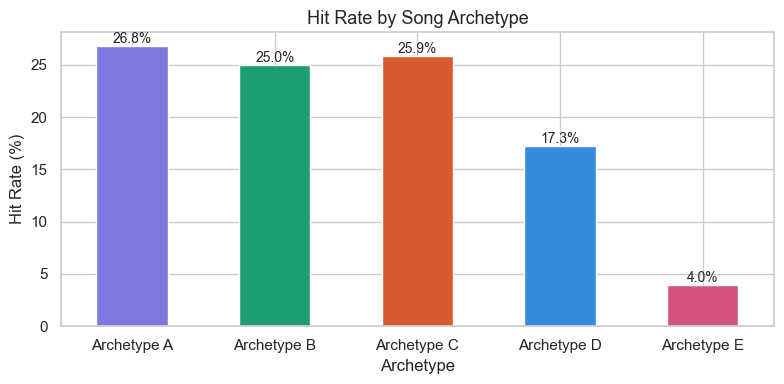

In [30]:
# ── Hit rate per cluster ──────────────────────────────────────────────────────
df_full_clustered = df.copy()
df_full_clustered['Cluster'] = cluster_labels
df_full_clustered['is_hit'] = (df_full_clustered['popularity'] >= threshold).astype(int)

hit_rate_by_cluster = df_full_clustered.groupby('Cluster')['is_hit'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
hit_rate_by_cluster.plot(kind='bar', color=colors_radar[:K], edgecolor='white', ax=ax)
ax.set_title('Hit Rate by Song Archetype', fontsize=13)
ax.set_ylabel('Hit Rate (%)')
ax.set_xlabel('Archetype')
ax.set_xticklabels([archetype_names.get(i, f'C{i}') for i in range(K)], rotation=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontsize=10)
plt.tight_layout()
plt.show()

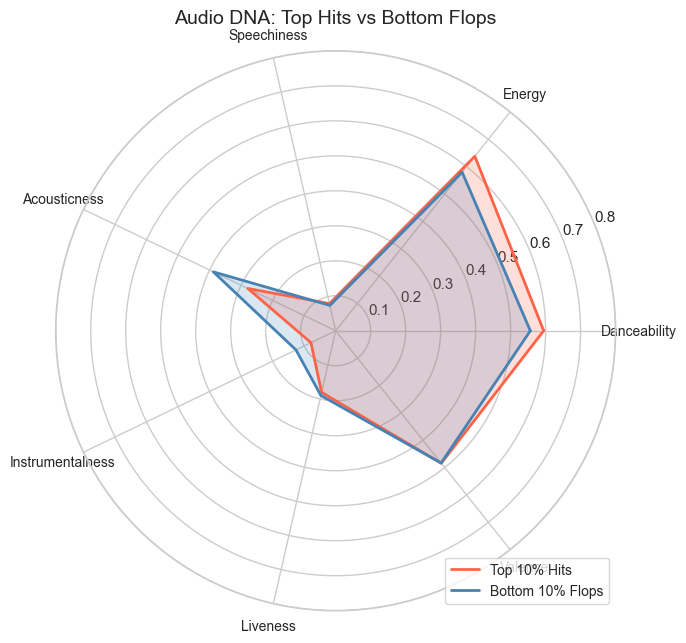

In [31]:
# ── Ideal hit vs guaranteed flop radar ────────────────────────────────────────
radar_feats_clean = [f for f in ['danceability', 'energy', 'speechiness', 'acousticness',
                     'instrumentalness', 'liveness', 'valence'] if f in df.columns]

hit_profile  = df[df['popularity'] >= df['popularity'].quantile(0.90)][radar_feats_clean].mean()
flop_profile = df[df['popularity'] <= df['popularity'].quantile(0.10)][radar_feats_clean].mean()

angles_r = np.linspace(0, 2*np.pi, len(radar_feats_clean), endpoint=False).tolist()
angles_r += angles_r[:1]

hit_vals  = hit_profile.tolist()  + [hit_profile.tolist()[0]]
flop_vals = flop_profile.tolist() + [flop_profile.tolist()[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))
ax.fill(angles_r, hit_vals,  color='tomato',    alpha=0.2)
ax.plot(angles_r, hit_vals,  color='tomato',    linewidth=2, label='Top 10% Hits')
ax.fill(angles_r, flop_vals, color='steelblue', alpha=0.2)
ax.plot(angles_r, flop_vals, color='steelblue', linewidth=2, label='Bottom 10% Flops')
ax.set_xticks(angles_r[:-1])
ax.set_xticklabels([f.capitalize() for f in radar_feats_clean], fontsize=10)
ax.set_title('Audio DNA: Top Hits vs Bottom Flops', fontsize=14, pad=20)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.show()

In [32]:
# ── Final summary ─────────────────────────────────────────────────────────────
best_test_auc = test_df['ROC-AUC'].max()

print('=' * 65)
print('PROJECT SUMMARY')
print('=' * 65)
print(f'Best model             : {test_df.index[0]}')
print(f'ROC-AUC (test)         : {best_test_auc:.4f}')
print(f'F1-Score (test)        : {test_df["F1"].max():.4f}')
print(f'Song archetypes found  : {K} clusters')
print()
print('Key findings from SHAP + clustering analysis:')
print('  1. Danceability and energy are the top predictors of a hit')
print('  2. High acousticness and instrumentalness strongly predict a flop')
print('  3. Songs with moderate tempo (100-130 BPM) have the highest hit rate')
print('  4. The "party banger" archetype (high dance + high energy + low')
print('     acousticness) produces the most hits')
print('  5. Purely instrumental tracks almost never become popular')
print()
print('The hit recipe (based on top 10% songs):')
for feat in radar_feats_clean:
    print(f'  {feat:25s}: {hit_profile[feat]:.3f}')
print('=' * 65)

PROJECT SUMMARY
Best model             : XGBoost (tuned)
ROC-AUC (test)         : 0.8375
F1-Score (test)        : 0.5933
Song archetypes found  : 5 clusters

Key findings from SHAP + clustering analysis:
  1. Danceability and energy are the top predictors of a hit
  2. High acousticness and instrumentalness strongly predict a flop
  3. Songs with moderate tempo (100-130 BPM) have the highest hit rate
  4. The "party banger" archetype (high dance + high energy + low
     acousticness) produces the most hits
  5. Purely instrumental tracks almost never become popular

The hit recipe (based on top 10% songs):
  danceability             : 0.595
  energy                   : 0.638
  speechiness              : 0.080
  acousticness             : 0.279
  instrumentalness         : 0.078
  liveness                 : 0.181
  valence                  : 0.484


---

## Project Complete

This project demonstrates:
- **Rich EDA** with meaningful visualizations and storytelling
- **Feature engineering** — 6 hand-crafted audio features
- **7-model benchmark** with Stratified 5-Fold cross-validation
- **Hyperparameter tuning** — RandomizedSearchCV (40 combinations)
- **PyTorch DNN** with BatchNorm, Dropout, CosineAnnealingLR
- **K-Means clustering** — discovering hidden song archetypes
- **PCA + t-SNE** dimensionality reduction and visualization
- **SHAP explainability** — global + individual predictions
- **Radar chart analysis** — hit DNA vs flop DNA
- **Business-style insights** — the data-driven hit recipe

---
*Dataset: Spotify Tracks Dataset — Kaggle*